In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [17]:
print(os.listdir())

['.config', 'sales_data.csv', '.ipynb_checkpoints', 'sample_data']


In [19]:
try:
    df = pd.read_csv("sales_data.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: sales_data.csv file not found.")

Dataset loaded successfully.


In [20]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100
Number of columns: 7


In [21]:
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [22]:
df.tail()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
95,2024-04-05,Tablet,8,20770,CUST096,North,166160
96,2024-04-06,Headphones,1,7647,CUST097,West,7647
97,2024-04-07,Tablet,5,27196,CUST098,East,135980
98,2024-04-08,Monitor,1,30717,CUST099,North,30717
99,2024-04-09,Headphones,5,23376,CUST100,South,116880


In [23]:
print(df.columns.tolist())

['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']


In [24]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['date', 'product', 'quantity', 'price', 'customer_id', 'region', 'total_sales']


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         100 non-null    object
 1   product      100 non-null    object
 2   quantity     100 non-null    int64 
 3   price        100 non-null    int64 
 4   customer_id  100 non-null    object
 5   region       100 non-null    object
 6   total_sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [26]:
df.describe()

,quantity,price,total_sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [27]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
date           0
product        0
quantity       0
price          0
customer_id    0
region         0
total_sales    0
dtype: int64


In [28]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
date           0.0
product        0.0
quantity       0.0
price          0.0
customer_id    0.0
region         0.0
total_sales    0.0
dtype: float64


In [29]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [30]:
if df.empty:
    print("Error: Dataset is empty.")
else:
    print("Dataset validation successful.")

Dataset validation successful.


In [31]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric columns:")
print(numeric_columns.tolist())

Numeric columns:
['quantity', 'price', 'total_sales']


In [32]:
text_columns = df.select_dtypes(include="object").columns

print("Text columns:")
print(text_columns.tolist())

Text columns:
['date', 'product', 'customer_id', 'region']


In [34]:
print("Available columns:")
print(df.columns.tolist())

Available columns:
['date', 'product', 'quantity', 'price', 'customer_id', 'region', 'total_sales']


In [35]:
print("Numeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Numeric columns:
['quantity', 'price', 'total_sales']


In [36]:
print("Text columns:")
print(df.select_dtypes(include="object").columns.tolist())

Text columns:
['date', 'product', 'customer_id', 'region']


In [37]:
for column in text_columns:
    print("\nColumn:", column)
    print(df[column].unique()[:10])


Column: date
['2024-01-01' '2024-01-02' '2024-01-03' '2024-01-04' '2024-01-05'
 '2024-01-06' '2024-01-07' '2024-01-08' '2024-01-09' '2024-01-10']

Column: product
['Phone' 'Headphones' 'Laptop' 'Tablet' 'Monitor']

Column: customer_id
['CUST001' 'CUST002' 'CUST003' 'CUST004' 'CUST005' 'CUST006' 'CUST007'
 'CUST008' 'CUST009' 'CUST010']

Column: region
['East' 'North' 'West' 'South']


In [38]:
df[numeric_columns].describe()

,quantity,price,total_sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [39]:
for column in numeric_columns:
    negative_count = (df[column] < 0).sum()
    print(f"{column}: {negative_count} negative values")

quantity: 0 negative values
price: 0 negative values
total_sales: 0 negative values


In [40]:
if df.empty:
    print("FAIL: Dataset is empty.")
else:
    print("PASS: Dataset contains data.")

if df.isnull().sum().sum() == 0:
    print("PASS: No missing values.")
else:
    print("WARNING: Missing values found.")

if df.duplicated().sum() == 0:
    print("PASS: No duplicate rows.")
else:
    print("WARNING: Duplicate rows found.")

PASS: Dataset contains data.
PASS: No missing values.
PASS: No duplicate rows.


In [41]:
df.head(10)

,date,product,quantity,price,customer_id,region,total_sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
5,2024-01-06,Laptop,7,40420,CUST006,South,282940
6,2024-01-07,Laptop,9,40430,CUST007,South,363870
7,2024-01-08,Laptop,7,7262,CUST008,West,50834
8,2024-01-09,Tablet,3,32791,CUST009,North,98373
9,2024-01-10,Laptop,4,45023,CUST010,West,180092


In [42]:
print("Rows after cleaning:", df.shape[0])
print("Columns after cleaning:", df.shape[1])

Rows after cleaning: 100
Columns after cleaning: 7


##Analysis

In [43]:
print("Available numeric columns:")
print(numeric_columns.tolist())

Available numeric columns:
['quantity', 'price', 'total_sales']


In [44]:
print("All columns in dataset:")
for i, column in enumerate(df.columns, start=1):
    print(i, "->", column)

All columns in dataset:
1 -> date
2 -> product
3 -> quantity
4 -> price
5 -> customer_id
6 -> region
7 -> total_sales


In [45]:
print("Numeric columns summary:")
print(df[numeric_columns].describe().T)

Numeric columns summary:
             count       mean            std     min       25%      50%  \
quantity     100.0       4.78       2.588163     1.0      2.75      5.0   
price        100.0   25808.51   13917.630242  1308.0  14965.25  24192.0   
total_sales  100.0  123650.48  100161.085275  6540.0  39517.50  97955.5   

                   75%       max  
quantity          7.00       9.0  
price         38682.25   49930.0  
total_sales  175792.50  373932.0  


In [46]:
possible_sales_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in ["sales", "sale", "revenue", "amount", "price"])
]

print("Possible sales-related columns:")
print(possible_sales_columns)

Possible sales-related columns:
['price', 'total_sales']


In [47]:
if len(possible_sales_columns) > 0:
    sales_column = possible_sales_columns[0]
    print("Selected sales column:", sales_column)
else:
    print("No sales-related column found.")

Selected sales column: price


In [48]:
if "sales_column" in globals():
    total_sales = df[sales_column].sum()
    print(f"Total Sales: ₹{total_sales:,.2f}")

Total Sales: ₹2,580,851.00


In [49]:
if "sales_column" in globals():
    average_sales = df[sales_column].mean()
    print(f"Average Sales: ₹{average_sales:,.2f}")

Average Sales: ₹25,808.51


In [50]:
if "sales_column" in globals():
    highest_sale = df[sales_column].max()
    print(f"Highest Sale: ₹{highest_sale:,.2f}")

Highest Sale: ₹49,930.00


In [51]:
if "sales_column" in globals():
    lowest_sale = df[sales_column].min()
    print(f"Lowest Sale: ₹{lowest_sale:,.2f}")

Lowest Sale: ₹1,308.00


In [52]:
print("===== SALES SUMMARY =====")

print(f"Total Sales   : ₹{total_sales:,.2f}")
print(f"Average Sales : ₹{average_sales:,.2f}")
print(f"Highest Sale  : ₹{highest_sale:,.2f}")
print(f"Lowest Sale   : ₹{lowest_sale:,.2f}")

===== SALES SUMMARY =====
Total Sales   : ₹2,580,851.00
Average Sales : ₹25,808.51
Highest Sale  : ₹49,930.00
Lowest Sale   : ₹1,308.00


In [53]:
possible_product_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in ["product", "item"])
]

print("Possible product columns:")
print(possible_product_columns)

Possible product columns:
['product']


In [54]:
if possible_product_columns:
    product_column = possible_product_columns[0]

    product_sales = (
        df.groupby(product_column)[sales_column]
        .sum()
        .sort_values(ascending=False)
    )

    print(product_sales)
else:
    print("Product column not found.")

product
Laptop        663636
Tablet        628608
Phone         547580
Headphones    430382
Monitor       310645
Name: price, dtype: int64


In [55]:
if possible_product_columns:
    best_product = product_sales.idxmax()
    best_product_sales = product_sales.max()

    print("Best-selling product:", best_product)
    print(f"Sales: ₹{best_product_sales:,.2f}")

Best-selling product: Laptop
Sales: ₹663,636.00


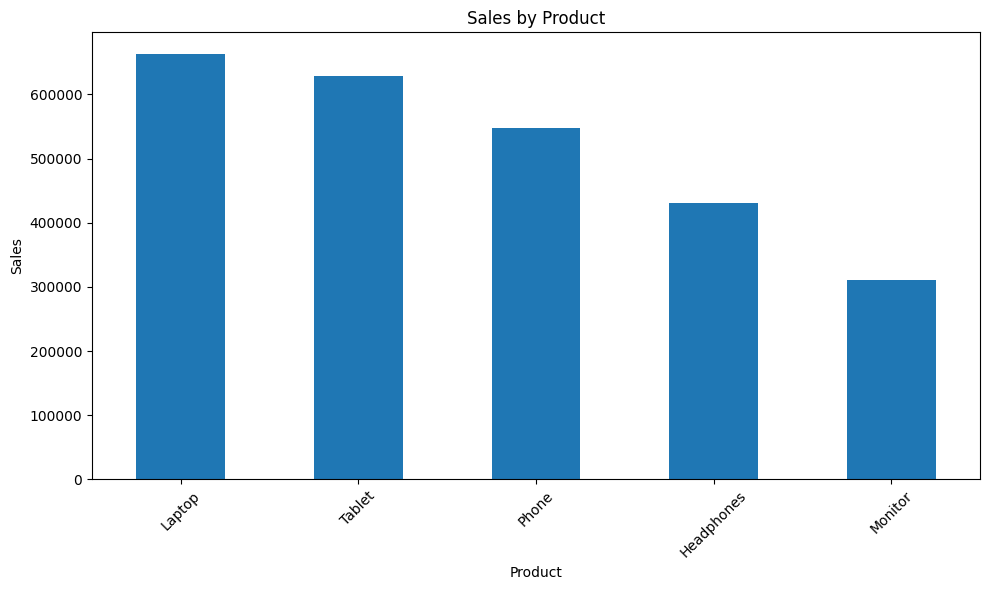

In [56]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

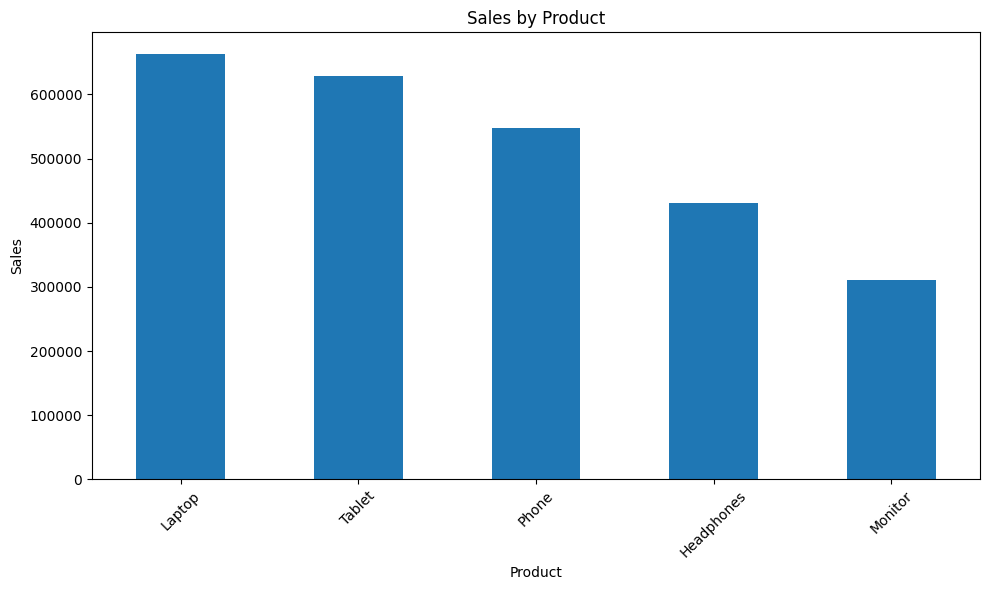

Bar chart saved successfully.


In [58]:
plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("sales_by_product.png")
plt.show()

print("Bar chart saved successfully.")

In [59]:
possible_category_columns = [
    col for col in df.columns
    if "category" in col.lower()
]

print("Possible category columns:")
print(possible_category_columns)

Possible category columns:
[]


In [60]:
if possible_category_columns:
    plt.figure(figsize=(8, 8))

    category_sales.plot(
        kind="pie",
        autopct="%1.1f%%"
    )

    plt.title("Sales Distribution by Category")
    plt.ylabel("")
    plt.tight_layout()

    plt.show()

In [61]:
if possible_category_columns:
    plt.figure(figsize=(8, 8))

    category_sales.plot(
        kind="pie",
        autopct="%1.1f%%"
    )

    plt.title("Sales Distribution by Category")
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("sales_by_category.png")
    plt.show()

    print("Pie chart saved successfully.")

In [62]:
print("=" * 45)
print("       E-COMMERCE SALES ANALYSIS")
print("=" * 45)

print(f"Total Sales       : ₹{total_sales:,.2f}")
print(f"Average Sales     : ₹{average_sales:,.2f}")
print(f"Highest Sale      : ₹{highest_sale:,.2f}")
print(f"Lowest Sale       : ₹{lowest_sale:,.2f}")

if possible_product_columns:
    print(f"Best Product      : {best_product}")

if possible_category_columns:
    best_category = category_sales.idxmax()
    print(f"Best Category     : {best_category}")

print("=" * 45)

       E-COMMERCE SALES ANALYSIS
Total Sales       : ₹2,580,851.00
Average Sales     : ₹25,808.51
Highest Sale      : ₹49,930.00
Lowest Sale       : ₹1,308.00
Best Product      : Laptop


In [63]:
print("===== FINAL VALIDATION =====")

print("Dataset rows:", len(df))
print("Dataset columns:", len(df.columns))

if df.empty:
    print("❌ Dataset is empty")
else:
    print("✅ Dataset is valid")

if df.isnull().sum().sum() == 0:
    print("✅ No missing values")
else:
    print("⚠️ Missing values found")

if df.duplicated().sum() == 0:
    print("✅ No duplicate rows")
else:
    print("⚠️ Duplicate rows found")

if os.path.exists("sales_by_product.png"):
    print("✅ Bar chart created")
else:
    print("❌ Bar chart missing")

if os.path.exists("sales_by_category.png"):
    print("✅ Pie chart created")
else:
    print("❌ Pie chart missing")

===== FINAL VALIDATION =====
Dataset rows: 100
Dataset columns: 7
✅ Dataset is valid
✅ No missing values
✅ No duplicate rows
✅ Bar chart created
❌ Pie chart missing


In [64]:
print("===== KEY INSIGHTS =====")

print(f"1. The total sales generated were ₹{total_sales:,.2f}.")
print(f"2. The average sale value was ₹{average_sales:,.2f}.")
print(f"3. The highest recorded sale was ₹{highest_sale:,.2f}.")
print(f"4. The lowest recorded sale was ₹{lowest_sale:,.2f}.")

if possible_product_columns:
    print(f"5. The best-selling product was {best_product}.")

if possible_category_columns:
    print(f"6. The highest-performing category was {best_category}.")

===== KEY INSIGHTS =====
1. The total sales generated were ₹2,580,851.00.
2. The average sale value was ₹25,808.51.
3. The highest recorded sale was ₹49,930.00.
4. The lowest recorded sale was ₹1,308.00.
5. The best-selling product was Laptop.


In [65]:
import os

folders = [
    "data",
    "visualizations",
    "report"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [66]:
import shutil

if os.path.exists("sales_data.csv"):
    shutil.copy("sales_data.csv", "data/sales_data.csv")
    print("Dataset copied to data folder.")
else:
    print("sales_data.csv not found.")

Dataset copied to data folder.


In [67]:
if os.path.exists("sales_by_product.png"):
    shutil.copy(
        "sales_by_product.png",
        "visualizations/sales_by_product.png"
    )
    print("Bar chart copied successfully.")
else:
    print("Bar chart not found.")

Bar chart copied successfully.


In [68]:
print("Files created in current folder:")

for file in os.listdir():
    if file.endswith(".png"):
        print(file)

Files created in current folder:
sales_by_product.png


In [69]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:", numeric_columns)

Numeric columns: ['quantity', 'price', 'total_sales']


In [70]:
if len(numeric_columns) > 1:
    histogram_column = numeric_columns[1]
else:
    histogram_column = numeric_columns[0]

print("Histogram column:", histogram_column)

Histogram column: price


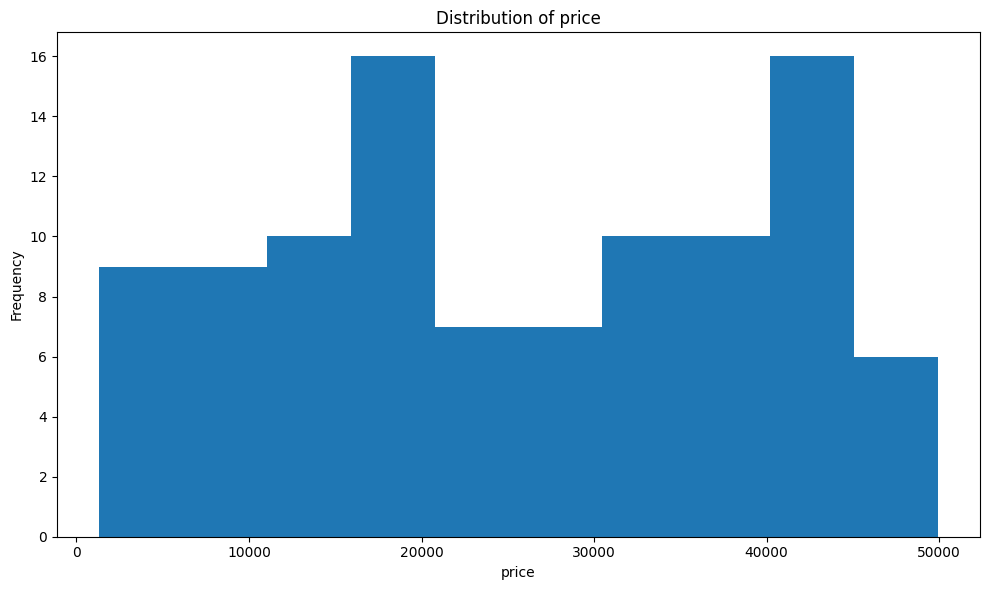

Histogram created successfully.


In [71]:
plt.figure(figsize=(10, 6))

plt.hist(df[histogram_column], bins=10)

plt.title(f"Distribution of {histogram_column}")
plt.xlabel(histogram_column)
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("sales_distribution.png")

plt.show()

print("Histogram created successfully.")

In [72]:
shutil.copy(
    "sales_distribution.png",
    "visualizations/sales_distribution.png"
)

print("Histogram copied to visualizations folder.")

Histogram copied to visualizations folder.


In [73]:
print("Visualization files:")

for file in os.listdir("visualizations"):
    print("✓", file)

Visualization files:
✓ sales_by_product.png
✓ sales_distribution.png


In [74]:
report_text = f"""
# E-commerce Sales Analysis Report

## 1. Introduction

This project analyzes sales data using Python, Pandas, NumPy, and Matplotlib.

The objective is to clean the dataset, calculate important metrics, identify patterns, and visualize the results.

## 2. Dataset

The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.

## 3. Data Cleaning

The following checks were performed:

- Dataset shape
- Column names
- Data types
- Missing values
- Duplicate records
- Numeric values
- Dataset validation

## 4. Analysis

### Total Sales

₹{total_sales:,.2f}

### Average Sales

₹{average_sales:,.2f}

### Highest Sale

₹{highest_sale:,.2f}

### Lowest Sale

₹{lowest_sale:,.2f}

"""

if possible_product_columns:
    report_text += f"""
### Best-Selling Product

{best_product}
"""

report_text += """
## 5. Visualizations

### Bar Chart

A bar chart was created to compare sales across products.

### Histogram

A histogram was created to understand the distribution of numerical sales data.

## 6. Key Insights

"""

report_text += f"""
- Total sales were ₹{total_sales:,.2f}.
- Average sales were ₹{average_sales:,.2f}.
- The highest recorded sale was ₹{highest_sale:,.2f}.
- The lowest recorded sale was ₹{lowest_sale:,.2f}.
"""

if possible_product_columns:
    report_text += f"- The best-selling product was {best_product}.\n"

report_text += """
## 7. Testing

The project was checked for:

- Dataset availability
- Missing values
- Duplicate records
- Empty dataset
- Valid numeric data
- Successful visualization generation

## 8. Conclusion

The project demonstrates a complete beginner-level data analysis pipeline from data loading and cleaning to analysis, visualization, validation, and reporting.
"""

with open("report/analysis_report.md", "w", encoding="utf-8") as file:
    file.write(report_text)

print("Analysis report created successfully.")

Analysis report created successfully.


In [75]:
requirements = """pandas
numpy
matplotlib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [76]:
print("===== FINAL PROJECT STRUCTURE =====")

for root, dirs, files in os.walk("."):
    if ".config" in root:
        continue

    level = root.replace(".", "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        if file.endswith((".csv", ".png", ".md", ".txt", ".ipynb")):
            print(f"{indent}    {file}")

===== FINAL PROJECT STRUCTURE =====
./
    sales_data.csv
    sales_by_product.png
    sales_distribution.png
    requirements.txt
    data/
        sales_data.csv
    .ipynb_checkpoints/
    report/
        analysis_report.md
    visualizations/
        sales_by_product.png
        sales_distribution.png
    sample_data/
        README.md
        california_housing_test.csv
        mnist_test.csv
        mnist_train_small.csv
        california_housing_train.csv


In [77]:
print("=" * 50)
print("       PROJECT COMPLETED SUCCESSFULLY")
print("=" * 50)

print("Dataset rows       :", df.shape[0])
print("Dataset columns    :", df.shape[1])
print(f"Total Sales        : ₹{total_sales:,.2f}")
print(f"Average Sales      : ₹{average_sales:,.2f}")
print(f"Highest Sale       : ₹{highest_sale:,.2f}")
print(f"Lowest Sale        : ₹{lowest_sale:,.2f}")

if possible_product_columns:
    print("Best Product       :", best_product)

print("\nCharts:")
print("✓ Bar Chart")
print("✓ Histogram")

print("\nDocumentation:")
print("✓ Analysis Report")
print("✓ Requirements File")

print("\nProject Status: READY FOR GITHUB")
print("=" * 50)

       PROJECT COMPLETED SUCCESSFULLY
Dataset rows       : 100
Dataset columns    : 7
Total Sales        : ₹2,580,851.00
Average Sales      : ₹25,808.51
Highest Sale       : ₹49,930.00
Lowest Sale        : ₹1,308.00
Best Product       : Laptop

Charts:
✓ Bar Chart
✓ Histogram

Documentation:
✓ Analysis Report
✓ Requirements File

Project Status: READY FOR GITHUB


In [84]:
readme_content = """# 🛒 E-commerce Sales Analysis

## 📌 Project Overview

This project performs a complete analysis of an E-commerce Sales Dataset using Python.

The project includes data loading, cleaning, validation, analysis, visualization, and documentation.

## 🎯 Objectives

- Load and explore the dataset
- Clean the data
- Check missing values and duplicates
- Perform sales analysis
- Create visualizations
- Generate meaningful insights
- Validate the data

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

## 📊 Analysis Performed

- Total Sales
- Average Sales
- Highest Sale
- Lowest Sale
- Best-Selling Product
- Product-wise Sales

## 📈 Visualizations

The project contains two different chart types:

1. Sales by Product - Bar Chart
2. Sales Distribution - Histogram

Charts are stored in the `visualizations/` folder.

## 🧹 Data Cleaning

The project checks:

- Missing values
- Duplicate records
- Numeric data
- Text data
- Negative values
- Empty dataset

## 📁 Project Structure

ecommerce-sales-analysis/

- README.md
- Ecommerce_Sales_Analysis.ipynb
- requirements.txt
- data/
- visualizations/
- report/

## 🧪 Testing

The project includes basic error handling and data validation to make sure the dataset is loaded and processed correctly.

## 🚀 Project Workflow

Data Loading
→ Data Cleaning
→ Data Validation
→ Data Analysis
→ Visualization
→ Insights
→ Final Report

## 👨‍💻 Author

**Nitish Kumar**

B.Tech Computer Science & Engineering Student
Aspiring Data Analyst | Data Science Enthusiast

GitHub: https://github.com/singhnitish11

## ⭐ Project Status

**Completed ✅**

Hands-on Data Analysis Project
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md created successfully!")

README.md created successfully!
